In [1]:
%load_ext autoreload
%autoreload 2

In [ ]:
from agents import RandomAgent
from briscola import Briscola

In [ ]:
def play_game(env, agent, n_games=100):
    wins = 0

    for _ in range(n_games):
        obs, _ = env.reset()
        done = False

        while not done:
            mask = env._get_action_mask()
            action = agent.act(obs, mask)

            obs, reward, terminated, truncated, _ = env.step(action)
            done = terminated or truncated

        if env.player_score > env.opponent_score:
            wins += 1

    return wins / n_games

In [ ]:
agent = RandomAgent()
env = Briscola()
win_rate = play_game(env, agent, 1000)

print("Win rate:", win_rate)

In [ ]:
env.action_space.n

In [ ]:
state, info = env.reset()
len(state)

In [2]:
import random
import math
import matplotlib
import matplotlib.pyplot as plt
from collections import namedtuple, deque
from itertools import count
import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim

from briscola import Briscola
from agents import *

In [3]:
BATCH_SIZE = 128 # number of transitions sampled from the replay buffer
GAMMA = 0.999 # discount factor
EPS_START = 0.9 # starting value of epsilon
EPS_END = 0.01 # final value of epsilon
EPS_DECAY = 50_000 # the rate of exponential decay of epsilon, higher means a slower decay
TAU = 0.005 # update rate of the target network
LR = 3e-4 # the learning rate of the ``AdamW`` optimizer

In [4]:
env = Briscola()

# set up matplotlib
is_ipython = 'inline' in matplotlib.get_backend()
if is_ipython:
    from IPython import display

plt.ion()

# if GPU is to be used
device = torch.device(
    "cuda" if torch.cuda.is_available() else
    "mps" if torch.backends.mps.is_available() else
    "cpu"
)

In [5]:
def flatten_obs(obs):
    # hand = obs["hand"].copy()
    # hand = np.where(hand == -1, 0, hand) / 40.0
    return np.concatenate([
        obs["hand"],
        obs["table_card"],
        obs["briscola"],
        obs["played_cards"],
        obs["is_first"]
    ]).astype(np.float32)

In [6]:
# Get number of actions from gym action space
n_actions = env.action_space.n
# Get the number of state observations
state, info = env.reset()
# n_observations = len(state)
n_observations = len(flatten_obs(state))

policy_net = DQN(n_observations, n_actions).to(device)
target_net = DQN(n_observations, n_actions).to(device)
target_net.load_state_dict(policy_net.state_dict())

optimizer = optim.AdamW(policy_net.parameters(), lr=LR, amsgrad=True)
memory = ReplayMemory(100_000)


steps_done = 0


def select_action(state, action_mask):
    global steps_done
    eps_threshold = EPS_END + (EPS_START - EPS_END) * \
        math.exp(-1. * steps_done / EPS_DECAY)
    steps_done += 1
    
    # EXPLOIT (use model)
    if random.random() > eps_threshold:
        with torch.no_grad():
            q_values = policy_net(state)  # shape: [1, 3]

            # Convert mask to tensor
            mask = torch.tensor(action_mask, device=device).unsqueeze(0)

            # Mask invalid actions
            q_values[mask == 0] = -1e9

            return q_values.max(1).indices.view(1, 1)

    # EXPLORE (random valid)
    else:
        valid_actions = np.where(action_mask == 1)[0]
        action = np.random.choice(valid_actions)

        return torch.tensor([[action]], device=device, dtype=torch.long)


episode_rewards = []


def plot_rewards(show_result=False):
    plt.figure(1)
    rewards_t = torch.tensor(episode_rewards, dtype=torch.float)

    if show_result:
        plt.title('Result')
    else:
        plt.clf()
        plt.title('Training...')

    plt.xlabel('Episode')
    plt.ylabel('Total Reward')

    # Plot raw rewards
    plt.plot(rewards_t.numpy(), label="Episode Reward")

    # Plot moving average (100 episodes)
    if len(rewards_t) >= 100:
        means = rewards_t.unfold(0, 100, 1).mean(1).view(-1)
        means = torch.cat((torch.zeros(99), means))
        plt.plot(means.numpy(), label="100-episode avg")

    plt.legend()
    plt.pause(0.001)

    if is_ipython:
        if not show_result:
            display.display(plt.gcf())
            display.clear_output(wait=True)
        else:
            display.display(plt.gcf())

In [7]:
def optimize_model():
    if len(memory) < BATCH_SIZE:
        return
    transitions = memory.sample(BATCH_SIZE)
    batch = Transition(*zip(*transitions))

    # Compute a mask of non-final states and concatenate the batch elements
    # (a final state would've been the one after which simulation ended)
    non_final_mask = torch.tensor(tuple(map(lambda s: s is not None,
                                          batch.next_state)), device=device, dtype=torch.bool)
    non_final_next_states = torch.cat([s for s in batch.next_state
                                                if s is not None])
    state_batch = torch.cat(batch.state)
    action_batch = torch.cat(batch.action)
    reward_batch = torch.cat(batch.reward)

    # Compute Q(s_t, a) - the model computes Q(s_t), then we select the
    # columns of actions taken. These are the actions which would've been taken
    # for each batch state according to policy_net
    state_action_values = policy_net(state_batch).gather(1, action_batch)

    # Compute V(s_{t+1}) for all next states.
    # Expected values of actions for non_final_next_states are computed based
    # on the "older" target_net; selecting their best reward with max(1).values
    # This is merged based on the mask, such that we'll have either the expected
    # state value or 0 in case the state was final.
    next_state_values = torch.zeros(BATCH_SIZE, device=device)
    with torch.no_grad():
        next_state_values[non_final_mask] = target_net(non_final_next_states).max(1).values
    # Compute the expected Q values
    expected_state_action_values = (next_state_values * GAMMA) + reward_batch

    # Compute Huber loss
    criterion = nn.SmoothL1Loss()
    loss = criterion(state_action_values, expected_state_action_values.unsqueeze(1))

    # Optimize the model
    optimizer.zero_grad()
    loss.backward()
    # In-place gradient clipping
    torch.nn.utils.clip_grad_value_(policy_net.parameters(), 100)
    optimizer.step()

Complete


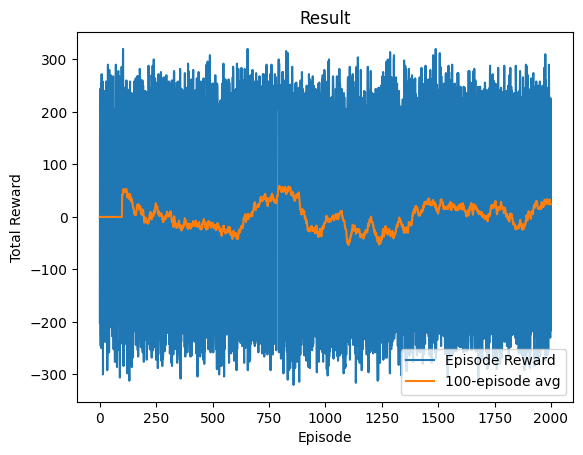

<Figure size 640x480 with 0 Axes>

<Figure size 640x480 with 0 Axes>

In [8]:
if torch.cuda.is_available() or torch.backends.mps.is_available():
    num_episodes = 2_000
else:
    num_episodes = 50

win_rates = []

for i_episode in range(num_episodes):
    # Initialize the environment and get its state
    state, info = env.reset()
    state = flatten_obs(state)
    state = torch.tensor(state, dtype=torch.float32, device=device).unsqueeze(0)
    total_reward = 0
    done = False
    while not done:
        action_mask = info["action_masks"]
        action = select_action(state, action_mask)
        observation, reward, terminated, truncated, info = env.step(action.item())
        observation = flatten_obs(observation)
        reward = torch.tensor([reward], device=device)
        done = terminated or truncated

        if terminated:
            next_state = None
        else:
            next_state = torch.tensor(observation, dtype=torch.float32, device=device).unsqueeze(0)

        # Store the transition in memory
        memory.push(state, action, next_state, reward)

        # Move to the next state
        state = next_state

        # Perform one step of the optimization (on the policy network)
        optimize_model()

        # Soft update of the target network's weights
        # θ′ ← τ θ + (1 −τ )θ′
        target_net_state_dict = target_net.state_dict()
        policy_net_state_dict = policy_net.state_dict()
        for key in policy_net_state_dict:
            target_net_state_dict[key] = policy_net_state_dict[key]*TAU + target_net_state_dict[key]*(1-TAU)
        target_net.load_state_dict(target_net_state_dict)

        total_reward += reward.item()  # Convert to scalar
    episode_rewards.append(total_reward)
    
    # Track win rate every 100 episodes
    if (i_episode + 1) % 100 == 0:
        wins = sum(1 for r in episode_rewards[-100:] if r > 0)  # Assuming positive reward means win
        win_rate = wins / 100
        win_rates.append(win_rate)
        print(f"Episode {i_episode+1}: Win rate last 100: {win_rate:.3f}")
    
    plot_rewards()

print('Complete')
plot_rewards(show_result=True)
plt.ioff()
plt.show()

In [ ]:
n_observations

In [ ]:
episode_rewards[0].dtype

In [11]:
np.mean(episode_rewards)
# episode_rewards.type(torch.float32).mean()
# new = [x for x in episode_rewards]
# mean = torch.mean(torch.stack(new))

np.float64(2.505)

In [12]:
# Evaluate the trained agent
def evaluate_agent(env, agent, n_games=1000):
    wins = 0
    total_rewards = []
    
    for _ in range(n_games):
        obs, info = env.reset()
        obs = flatten_obs(obs)
        obs = torch.tensor(obs, dtype=torch.float32, device=device).unsqueeze(0)
        done = False
        episode_reward = 0
        
        while not done:
            mask = info["action_masks"]
            with torch.no_grad():
                q_values = policy_net(obs)
                mask_tensor = torch.tensor(mask, device=device).unsqueeze(0)
                q_values[mask_tensor == 0] = -1e9
                action = q_values.max(1).indices.view(1, 1)
            
            obs_next, reward, terminated, truncated, info = env.step(action.item())
            obs_next = flatten_obs(obs_next)
            obs_next = torch.tensor(obs_next, dtype=torch.float32, device=device).unsqueeze(0)
            obs = obs_next
            episode_reward += reward
            done = terminated or truncated
        
        if env.player_score > env.opponent_score:
            wins += 1
        total_rewards.append(episode_reward)
    
    win_rate = wins / n_games
    mean_reward = np.mean(total_rewards)
    print(f"Win rate: {win_rate:.3f}")
    print(f"Mean reward: {mean_reward:.3f}")
    return win_rate, mean_reward

win_rate, mean_reward = evaluate_agent(env, policy_net, 1000)

Win rate: 0.528
Mean reward: 17.090


In [13]:
# Inspect Q-values for a sample state
def inspect_q_values(env, policy_net, num_samples=5):
    for i in range(num_samples):
        obs, info = env.reset()
        obs_flat = flatten_obs(obs)
        obs_tensor = torch.tensor(obs_flat, dtype=torch.float32, device=device).unsqueeze(0)
        
        with torch.no_grad():
            q_values = policy_net(obs_tensor).squeeze(0).cpu().numpy()
        
        mask = info["action_masks"]
        valid_indices = np.where(mask == 1)[0]
        
        print(f"Sample {i+1}:")
        print(f"  Hand: {[f'{idx//10}-{idx%10+1}' for idx in valid_indices]}")
        print(f"  Briscola suit: {np.argmax(obs['briscola'])}")
        print(f"  Is first: {obs['is_first'][0]}")
        print(f"  Table: {obs['table_card']}")
        print(f"  Q-values for valid actions: {q_values[valid_indices]}")
        print(f"  Best action: {valid_indices[np.argmax(q_values[valid_indices])]} (Q={np.max(q_values[valid_indices]):.3f})")
        print()

inspect_q_values(env, policy_net, 3)

Sample 1:
  Hand: ['0-4', '0-9', '1-1']
  Briscola suit: 3
  Is first: 0
  Table: [0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0
 0 0 1]
  Q-values for valid actions: [3.5203875e+06 3.2133368e+06 3.2607410e+06]
  Best action: 3 (Q=3520387.500)

Sample 2:
  Hand: ['1-6', '1-10', '2-2']
  Briscola suit: 1
  Is first: 0
  Table: [0 0 0 0 0 0 0 1 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0
 0 0 0]
  Q-values for valid actions: [2.2570608e+06 2.3498438e+06 2.3669060e+06]
  Best action: 21 (Q=2366906.000)

Sample 3:
  Hand: ['0-2', '0-3', '2-8']
  Briscola suit: 1
  Is first: 0
  Table: [0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 1 0 0 0 0 0 0 0
 0 0 0]
  Q-values for valid actions: [2.2052015e+06 2.3618060e+06 2.3848330e+06]
  Best action: 27 (Q=2384833.000)



___

# 2. PPO Agent

In [ ]:
import numpy as np
import torch
from briscola import Briscola
from ppo_agent import BriscolaNet, PPO, RolloutBuffer

# ── Hyperparameters ──────────────────────────────────────────
ROLLOUT_STEPS  = 2048   # steps to collect before each update
TOTAL_STEPS    = 3_000_000
LR             = 3e-4
GAMMA          = 0.99
GAE_LAMBDA     = 0.95
CLIP_EPS       = 0.2
VALUE_COEF     = 0.5
ENTROPY_COEF   = 0.03   # increase to 0.05 if agent gets stuck early
N_EPOCHS       = 10
BATCH_SIZE     = 64
MAX_GRAD_NORM  = 0.5
HIDDEN         = 128
LOG_INTERVAL   = 10     # log every N updates
# ─────────────────────────────────────────────────────────────

device = torch.device("cuda" if torch.cuda.is_available() else
                      "mps"  if torch.backends.mps.is_available() else "cpu")

def flatten_obs(obs: dict) -> np.ndarray:
    return np.concatenate([
        obs["hand"].astype(np.float32),
        obs["table_card"].astype(np.float32),
        obs["briscola"].astype(np.float32),
        obs["played_cards"].astype(np.float32),
        obs["is_first"].astype(np.float32),
    ])

env       = Briscola()
obs_dim   = len(flatten_obs(env.reset()[0]))
n_actions = env.action_space.n   # 40

net = BriscolaNet(obs_dim, n_actions, hidden=HIDDEN).to(device)
agent = PPO(
    net, lr=LR, gamma=GAMMA, gae_lambda=GAE_LAMBDA,
    clip_eps=CLIP_EPS, value_coef=VALUE_COEF,
    entropy_coef=ENTROPY_COEF, n_epochs=N_EPOCHS,
    batch_size=BATCH_SIZE, max_grad_norm=MAX_GRAD_NORM,
    device=str(device),
)

buffer = RolloutBuffer()

obs, info   = env.reset()
state       = flatten_obs(obs)
action_mask = info["action_masks"]

episode_rewards = []
ep_reward       = 0.0
total_steps     = 0
n_updates       = 0

while total_steps < TOTAL_STEPS:

    # ── Phase 1: collect ROLLOUT_STEPS transitions ──
    buffer.clear()
    for _ in range(ROLLOUT_STEPS):
        state_t = torch.tensor(state, dtype=torch.float32, device=device).unsqueeze(0)
        mask_t  = torch.tensor(action_mask, dtype=torch.bool, device=device).unsqueeze(0)

        with torch.no_grad():
            action, log_prob, _, value = net.get_action(state_t, mask_t)

        a = action.item()
        next_obs, reward, terminated, truncated, info = env.step(a)
        done = terminated or truncated

        buffer.states.append(state)
        buffer.actions.append(a)
        buffer.log_probs.append(log_prob.item())
        buffer.rewards.append(reward)
        buffer.values.append(value.item())
        buffer.masks.append(action_mask)
        buffer.dones.append(float(done))

        ep_reward += reward
        total_steps += 1

        if done:
            episode_rewards.append(ep_reward)
            ep_reward = 0.0
            obs, info = env.reset()
        else:
            obs = next_obs

        state       = flatten_obs(obs)
        action_mask = info["action_masks"]

    # ── Phase 2 & 3: compute GAE + update ──
    last_state_t = torch.tensor(state, dtype=torch.float32, device=device).unsqueeze(0)
    last_mask_t  = torch.tensor(action_mask, dtype=torch.bool, device=device).unsqueeze(0)
    with torch.no_grad():
        _, last_value = net(last_state_t)
    last_value = last_value.item()

    stats = agent.update(buffer, last_value)
    n_updates += 1

    if n_updates % LOG_INTERVAL == 0 and episode_rewards:
        recent = episode_rewards[-100:]
        print(
            f"Steps: {total_steps:>8,} | "
            f"Updates: {n_updates:>4} | "
            f"Mean reward (100 ep): {np.mean(recent):+.2f} | "
            f"Policy loss: {stats['policy_loss']:+.4f} | "
            f"Value loss: {stats['value_loss']:.4f} | "
            f"Entropy: {stats['entropy']:.4f}"
        )

torch.save(net.state_dict(), "briscola_ppo.pt")
print("Saved.")